# Stage 8: Simulation Results

This notebook summarizes Stage 8 outputs from `results/simulation` for the available feature-selection methods.

It includes:
- data coverage and schema checks
- numeric summary tables (recall/FDR)
- plots by signal type, effect size, and top-k setting

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "simulation").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / "results" / "simulation"
METHODS = ["ttest", "random", "rf_shap"]

recall_frames = []
fdr_frames = []
meta_rows = []

for method in METHODS:
    recall_path = RESULTS_ROOT / method / "recall.parquet"
    fdr_path = RESULTS_ROOT / method / "fdr.parquet"
    meta_path = RESULTS_ROOT / method / "meta.json"

    if not recall_path.exists() or not fdr_path.exists():
        print(f"[WARN] Missing recall/fdr parquet for method='{method}' under {RESULTS_ROOT / method}")
        continue

    recall_method = pd.read_parquet(recall_path).copy()
    recall_method["method"] = method
    recall_frames.append(recall_method)

    fdr_method = pd.read_parquet(fdr_path).copy()
    fdr_method["method"] = method
    fdr_frames.append(fdr_method)

    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        meta_rows.append(
            {
                "method": method,
                "n_recall_rows_meta": meta.get("n_recall_rows"),
                "n_fdr_rows_meta": meta.get("n_fdr_rows"),
                "n_repeats": meta.get("n_repeats"),
                "n_features": meta.get("n_features"),
                "signals_per_type": meta.get("signals_per_type"),
                "effect_sizes": ", ".join(map(str, meta.get("effect_sizes", []))),
                "topk_values": ", ".join(map(str, meta.get("topk_values", []))),
                "includes_native": meta.get("includes_native"),
                "runtime_seconds": meta.get("runtime_seconds"),
            }
        )

if not recall_frames or not fdr_frames:
    raise FileNotFoundError(f"No simulation result files found under {RESULTS_ROOT}")

recall_df = pd.concat(recall_frames, ignore_index=True)
fdr_df = pd.concat(fdr_frames, ignore_index=True)
recall_df["k"] = recall_df["k"].astype(str)
fdr_df["k"] = fdr_df["k"].astype(str)

k_order = ["10", "25", "50", "100", "native"]
signal_order = ["linear", "bounded_variance", "threshold", "u_shape", "xor_pair"]

recall_df["k"] = pd.Categorical(recall_df["k"], categories=k_order, ordered=True)
recall_df["signal_type"] = pd.Categorical(recall_df["signal_type"], categories=signal_order, ordered=True)
fdr_df["k"] = pd.Categorical(fdr_df["k"], categories=k_order, ordered=True)

print(f"Detected project root: {ROOT}")
print(f"Loaded recall rows: {len(recall_df):,} | fdr rows: {len(fdr_df):,}")
recall_df.head()

Detected project root: c:\Programmering\exjobb\MSc26_Proteomics
Loaded recall rows: 11,250 | fdr rows: 750


,repeat,signal_type,effect_size,k,recall,method
0,1,bounded_variance,0.3,10,0.0,ttest
1,1,bounded_variance,0.3,100,1.0,ttest
2,1,bounded_variance,0.3,25,0.0,ttest
3,1,bounded_variance,0.3,50,0.0,ttest
4,1,bounded_variance,0.3,native,0.0,ttest


In [2]:
meta_df = pd.DataFrame(meta_rows).set_index("method") if meta_rows else pd.DataFrame()

recall_coverage = (
    recall_df.groupby("method", observed=False)
    .agg(
        n_rows=("repeat", "size"),
        repeats=("repeat", "nunique"),
        signal_types=("signal_type", "nunique"),
        effect_sizes=("effect_size", "nunique"),
        k_values=("k", "nunique"),
    )
    .sort_index()
)

fdr_coverage = (
    fdr_df.groupby("method", observed=False)
    .agg(
        n_rows=("repeat", "size"),
        repeats=("repeat", "nunique"),
        k_values=("k", "nunique"),
    )
    .sort_index()
)

print("Meta summary")
display(meta_df)

print("Observed recall coverage")
display(recall_coverage)

print("Observed fdr coverage")
display(fdr_coverage)

if not meta_df.empty:
    compare = recall_coverage[["n_rows"]].rename(columns={"n_rows": "recall_n_rows"})
    compare["recall_n_rows_meta"] = meta_df["n_recall_rows_meta"]
    compare["fdr_n_rows"] = fdr_coverage["n_rows"]
    compare["fdr_n_rows_meta"] = meta_df["n_fdr_rows_meta"]
    compare["recall_matches"] = compare["recall_n_rows"] == compare["recall_n_rows_meta"]
    compare["fdr_matches"] = compare["fdr_n_rows"] == compare["fdr_n_rows_meta"]
    print("Row count validation")
    display(compare)

Meta summary


,n_recall_rows_meta,n_fdr_rows_meta,n_repeats,n_features,signals_per_type,effect_sizes,topk_values,includes_native,runtime_seconds
method,,,,,,,,,
ttest,3750,250,50,100,3,"0.3, 0.6, 1.0","10, 25, 50, 100",True,71.406736
random,3750,250,50,100,3,"0.3, 0.6, 1.0","10, 25, 50, 100",True,70.122706
rf_shap,3750,250,50,100,3,"0.3, 0.6, 1.0","10, 25, 50, 100",True,189.786295


Observed recall coverage


,n_rows,repeats,signal_types,effect_sizes,k_values
method,,,,,
random,3750,50,5,3,5
rf_shap,3750,50,5,3,5
ttest,3750,50,5,3,5


Observed fdr coverage


,n_rows,repeats,k_values
method,,,
random,250,50,5
rf_shap,250,50,5
ttest,250,50,5


Row count validation


,recall_n_rows,recall_n_rows_meta,fdr_n_rows,fdr_n_rows_meta,recall_matches,fdr_matches
method,,,,,,
random,3750,3750,250,250,True,True
rf_shap,3750,3750,250,250,True,True
ttest,3750,3750,250,250,True,True


In [3]:
recall_summary_method_k = (
    recall_df.groupby(["method", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"))
    .reset_index()
    .round(3)
)

fdr_summary_method_k = (
    fdr_df.groupby(["method", "k"], observed=False)
    .agg(
        fdr_mean=("fdr", "mean"),
        fdr_std=("fdr", "std"),
        n_selected_mean=("n_selected", "mean"),
    )
    .reset_index()
    .round(3)
)

print("Recall mean/SD by method and k")
display(recall_summary_method_k)
print("Recall mean pivot (k x method)")
display(recall_summary_method_k.pivot(index="k", columns="method", values="recall_mean"))

print("FDR mean/SD by method and k")
display(fdr_summary_method_k)
print("FDR mean pivot (k x method)")
display(fdr_summary_method_k.pivot(index="k", columns="method", values="fdr_mean"))

Recall mean/SD by method and k


,method,k,recall_mean,recall_std
0,random,10,0.097,0.159
1,random,25,0.242,0.230
2,random,50,0.503,0.263
3,random,100,1.000,0.000
4,random,native,0.195,0.211
5,rf_shap,10,0.222,0.359
6,rf_shap,25,0.488,0.421
7,rf_shap,50,0.723,0.329
8,rf_shap,100,1.000,0.000
9,rf_shap,native,0.000,0.000


Recall mean pivot (k x method)


method,random,rf_shap,ttest
k,,,
10,0.097,0.222,0.201
25,0.242,0.488,0.384
50,0.503,0.723,0.608
100,1.000,1.000,1.000
native,0.195,0.000,0.166


FDR mean/SD by method and k


,method,k,fdr_mean,fdr_std,n_selected_mean
0,random,10,0.466,0.175,10.00
1,random,25,0.457,0.089,25.00
2,random,50,0.451,0.047,50.00
3,random,100,0.460,0.000,100.00
4,random,native,0.456,0.100,20.00
5,rf_shap,10,0.000,0.000,10.00
6,rf_shap,25,0.094,0.053,25.00
7,rf_shap,50,0.277,0.043,50.00
8,rf_shap,100,0.460,0.000,100.00
9,rf_shap,native,NaN,NaN,0.00


FDR mean pivot (k x method)


method,random,rf_shap,ttest
k,,,
10,0.466,0.000,0.078
25,0.457,0.094,0.249
50,0.451,0.277,0.374
100,0.460,0.460,0.460
native,0.456,NaN,0.042


In [4]:
summary_signal_effect_k = (
    recall_df.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

# Per-k FDR is independent of signal_type/effect_size — looked up separately for tie-breaking only.
fdr_per_k = (
    fdr_df.groupby(["method", "k"], observed=False)
    .agg(fdr_mean=("fdr", "mean"))
    .reset_index()
)

focus_native_25 = summary_signal_effect_k[summary_signal_effect_k["k"].isin(["25", "native"])].copy()
focus_native_25["recall_mean"] = focus_native_25["recall_mean"].round(3)

print("Signal/effect recall summary for k=25 vs native")
display(focus_native_25.head(30))

best_recall_by_signal = (
    summary_signal_effect_k
    .merge(fdr_per_k, on=["method", "k"], how="left")
    .sort_values(
        ["method", "signal_type", "effect_size", "recall_mean", "fdr_mean"],
        ascending=[True, True, True, False, True],
    )
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .head(1)
    .rename(columns={"k": "best_k_by_recall"})
    .sort_values(["method", "signal_type", "effect_size"])
)

print("Best k by mean recall (tie-break: lower per-k FDR)")
display(
    best_recall_by_signal[
        ["method", "signal_type", "effect_size", "best_k_by_recall", "recall_mean", "fdr_mean"]
    ].round(3)
)

Signal/effect recall summary for k=25 vs native


,method,signal_type,effect_size,k,recall_mean
1,random,linear,0.3,25,0.227
4,random,linear,0.3,native,0.187
6,random,linear,0.6,25,0.227
9,random,linear,0.6,native,0.160
11,random,linear,1.0,25,0.207
14,random,linear,1.0,native,0.160
16,random,bounded_variance,0.3,25,0.233
19,random,bounded_variance,0.3,native,0.213
21,random,bounded_variance,0.6,25,0.207
24,random,bounded_variance,0.6,native,0.173


Best k by mean recall (tie-break: lower per-k FDR)


,method,signal_type,effect_size,best_k_by_recall,recall_mean,fdr_mean
3,random,linear,0.3,100,1.0,0.460
8,random,linear,0.6,100,1.0,0.460
13,random,linear,1.0,100,1.0,0.460
18,random,bounded_variance,0.3,100,1.0,0.460
23,random,bounded_variance,0.6,100,1.0,0.460
28,random,bounded_variance,1.0,100,1.0,0.460
33,random,threshold,0.3,100,1.0,0.460
38,random,threshold,0.6,100,1.0,0.460
43,random,threshold,1.0,100,1.0,0.460
48,random,u_shape,0.3,100,1.0,0.460


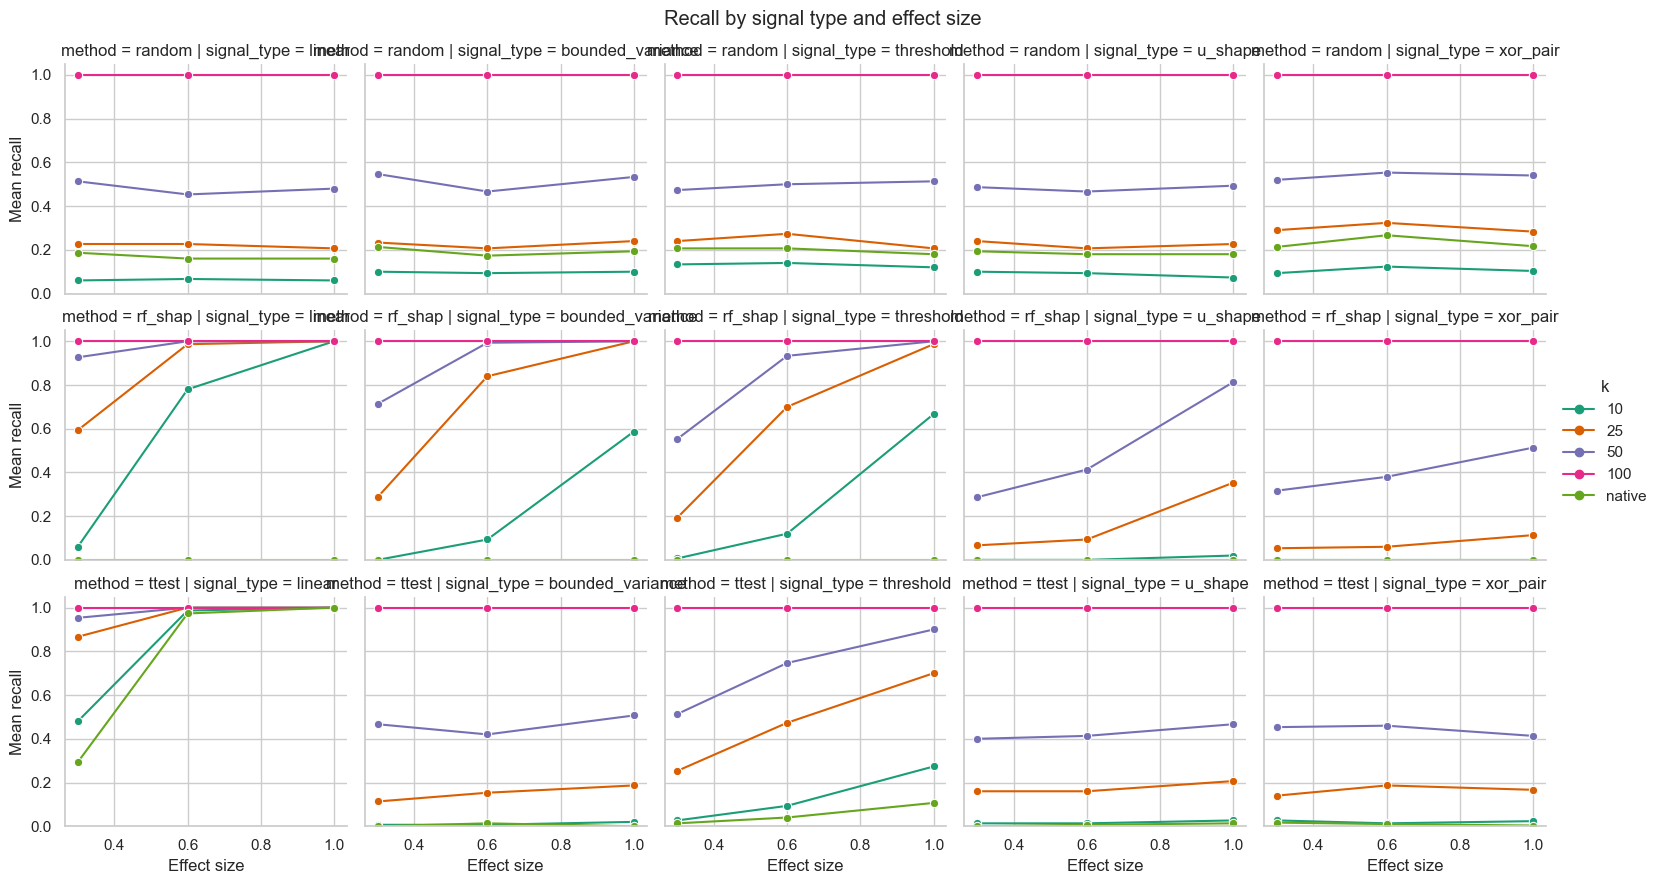

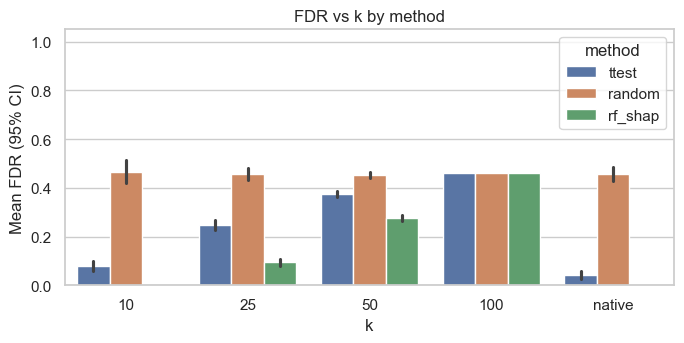

In [5]:
recall_plot_df = (
    recall_df.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

palette = {
    "10": "#1b9e77",
    "25": "#d95f02",
    "50": "#7570b3",
    "100": "#e7298a",
    "native": "#66a61e",
}

g_recall = sns.relplot(
    data=recall_plot_df,
    x="effect_size",
    y="recall_mean",
    hue="k",
    hue_order=k_order,
    col="signal_type",
    row="method",
    kind="line",
    marker="o",
    dashes=False,
    height=3.0,
    aspect=1.05,
    palette=palette,
)
g_recall.set(ylim=(0, 1.05))
g_recall.set_axis_labels("Effect size", "Mean recall")
g_recall.fig.subplots_adjust(top=0.92)
g_recall.fig.suptitle("Recall by signal type and effect size")
plt.show()

# FDR has no signal_type/effect_size dimension — one value per (method, k).
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.barplot(
    data=fdr_df,
    x="k",
    y="fdr",
    hue="method",
    order=k_order,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("k")
ax.set_ylabel("Mean FDR (95% CI)")
ax.set_title("FDR vs k by method")
fig.tight_layout()
plt.show()

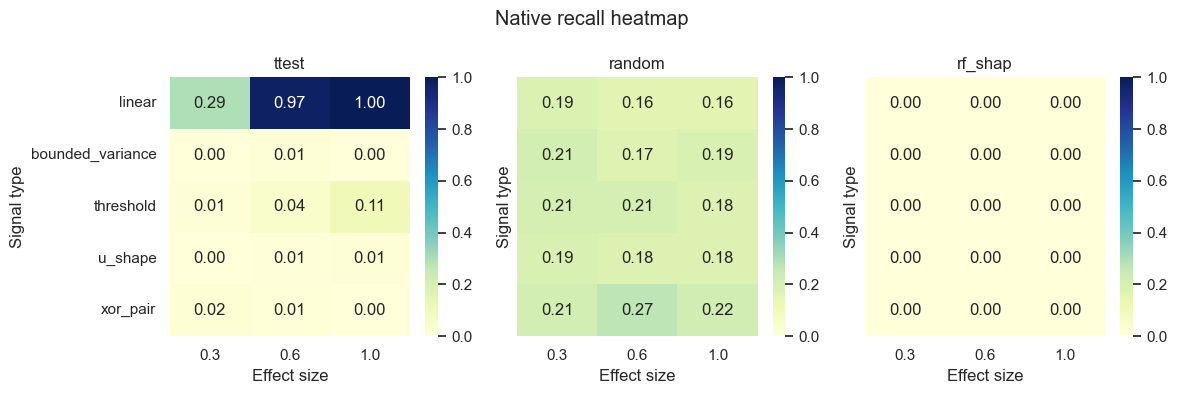

FDR per (method, k):


method,random,rf_shap,ttest
k,,,
10,0.466,0.000,0.078
25,0.457,0.094,0.249
50,0.451,0.277,0.374
100,0.460,0.460,0.460
native,0.456,NaN,0.042


In [6]:
native_df = (
    recall_df[recall_df["k"] == "native"]
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, len(METHODS), figsize=(12, 4), sharey=True)
if len(METHODS) == 1:
    axes = [axes]

for ax, method in zip(axes, METHODS):
    matrix = (
        native_df[native_df["method"] == method]
        .pivot(index="signal_type", columns="effect_size", values="recall_mean")
        .reindex(signal_order)
    )
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="YlGnBu",
        vmin=0.0, vmax=1.0, cbar=True, ax=ax,
    )
    ax.set_title(f"{method}")
    ax.set_xlabel("Effect size")
    ax.set_ylabel("Signal type")

fig.suptitle("Native recall heatmap")
fig.tight_layout()
plt.show()

# Per-(method, k) FDR table — the only grain on which FDR is defined.
print("FDR per (method, k):")
display(
    fdr_summary_method_k.pivot(index="k", columns="method", values="fdr_mean").round(3)
)

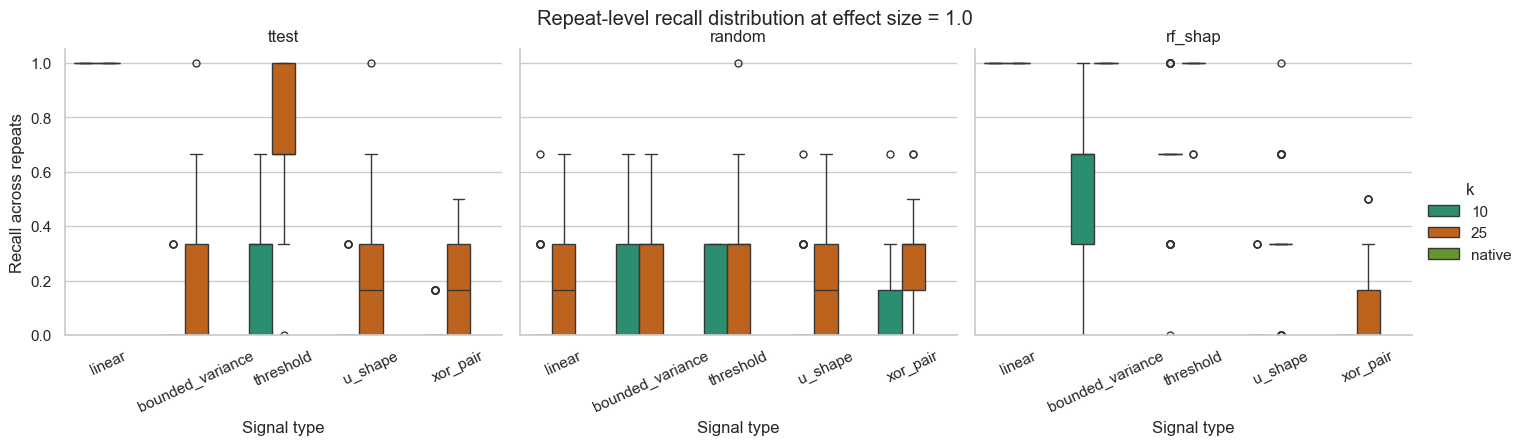

In [7]:
repeat_focus = recall_df[(recall_df["effect_size"] == 1.0) & (recall_df["k"].isin(["10", "25", "native"]))].copy()

box = sns.catplot(
    data=repeat_focus,
    x="signal_type",
    y="recall",
    hue="k",
    hue_order=["10", "25", "native"],
    col="method",
    kind="box",
    height=4,
    aspect=1.2,
    palette=palette,
)
box.set_axis_labels("Signal type", "Recall across repeats")
box.set_titles("{col_name}")
box.fig.subplots_adjust(top=0.88)
box.fig.suptitle("Repeat-level recall distribution at effect size = 1.0")
for ax in box.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
plt.show()